In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
# Parameter windowing
input_width = int(48)*8
label_width = 48
shift = label_width
total_window_size = input_width + shift
OUT_STEPS = label_width
# Definisikan irisan untuk input dan label
input_slice = slice(0, input_width)
label_start = total_window_size - label_width
labels_slice = slice(label_start, None)

from B_template import  scale_array, inverse_scale_array,  process_predictions, compute_metrics, compute_error, make_windows_autoregressive, make_windows

# data training

In [2]:
# data_training_awal= pd.read_excel('D:\\JAMALI FORECASTING\\PER_HARI\\DATA_HARI\\data_senin_train.xlsx', index_col=0)
# data_training= data_training_awal.astype('float32').copy()
# data_training

In [3]:
data_training_awal=  pd.read_excel('D:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_senin_train.xlsx', index_col=0)
data_training= data_training_awal.astype('float32').copy()
data_training

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
Date,,,,,,,,,
2022-01-03 00:00:00,19210.000000,0.000000,1.000000,0.0,1.0,0.0,1.000000e+00,1.012018,-4.183629
2022-01-03 00:30:00,19023.000000,0.130526,0.991445,0.0,1.0,0.0,1.000000e+00,1.012018,-4.457446
2022-01-03 01:00:00,18850.000000,0.258819,0.965926,0.0,1.0,0.0,1.000000e+00,1.012018,-4.731263
2022-01-03 01:30:00,18607.000000,0.382683,0.923880,0.0,1.0,0.0,1.000000e+00,1.012018,-4.907955
2022-01-03 02:00:00,18430.000000,0.500000,0.866025,0.0,1.0,0.0,1.000000e+00,1.012018,-5.084647
...,...,...,...,...,...,...,...,...,...
2024-10-28 21:30:00,29322.710938,-0.608761,0.793353,0.0,1.0,-1.0,-1.836970e-16,1.012018,0.852978
2024-10-28 22:00:00,28681.539062,-0.500000,0.866025,0.0,1.0,-1.0,-1.836970e-16,1.012018,0.531439
2024-10-28 22:30:00,28172.419922,-0.382683,0.923880,0.0,1.0,-1.0,-1.836970e-16,1.012018,0.260008


In [4]:
data_training.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,7104.000000,7.104000e+03,7.104000e+03,7104.0,7104.0,7.104000e+03,7.104000e+03,7104.000000,7104.000000
mean,25064.730469,0.000000e+00,0.000000e+00,0.0,1.0,3.263599e-02,-4.614950e-02,0.998120,-0.267581
std,3432.483154,7.071565e-01,7.071565e-01,0.0,0.0,7.040073e-01,7.080390e-01,0.051532,4.294808
min,13475.000000,-1.000000e+00,-1.000000e+00,0.0,1.0,-1.000000e+00,-1.000000e+00,0.697430,-10.782065
25%,22119.500000,-7.071068e-01,-7.071068e-01,0.0,1.0,-5.000000e-01,-8.660254e-01,1.012018,-3.797192
50%,25812.000000,6.123234e-17,-6.123234e-17,0.0,1.0,1.224647e-16,-1.836970e-16,1.012018,-1.212879
75%,27719.542969,7.071068e-01,7.071068e-01,0.0,1.0,8.660254e-01,5.000000e-01,1.012018,2.984569
max,32091.171875,1.000000e+00,1.000000e+00,0.0,1.0,1.000000e+00,1.000000e+00,1.012018,12.931227


In [5]:
data_training['Suhu_PCA'], min_suhu, max_suhu = scale_array(
    data_training['Suhu_PCA'].values, 
    new_min=-1,
    new_max=1)

data_training['Holiday_Impact'], min_holiday, max_holiday = scale_array(
    data_training['Holiday_Impact'].values, 
    new_min=-1, 
    new_max=1
)

data_training['Beban'], min_beban, max_beban = scale_array(
    data_training['Beban'].values, 
    new_min=-1, 
    new_max=1)

Computed orig_min: -10.782065391540527
Computed orig_max: 12.93122673034668
Computed orig_min: 0.6974297761917114
Computed orig_max: 1.0120183229446411
Computed orig_min: 13475.0
Computed orig_max: 32091.171875


In [6]:
data_training.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,7104.000000,7.104000e+03,7.104000e+03,7104.0,7104.0,7.104000e+03,7.104000e+03,7104.000000,7104.000000
mean,0.245125,0.000000e+00,0.000000e+00,0.0,1.0,3.263599e-02,-4.614950e-02,0.911644,-0.113199
std,0.368764,7.071565e-01,7.071565e-01,0.0,0.0,7.040073e-01,7.080390e-01,0.327615,0.362228
min,-1.000000,-1.000000e+00,-1.000000e+00,0.0,1.0,-1.000000e+00,-1.000000e+00,-1.000000,-1.000000
25%,-0.071291,-7.071068e-01,-7.071068e-01,0.0,1.0,-5.000000e-01,-8.660254e-01,1.000000,-0.410890
50%,0.325407,6.123234e-17,-6.123234e-17,0.0,1.0,1.224647e-16,-1.836970e-16,1.000000,-0.192926
75%,0.530341,7.071068e-01,7.071068e-01,0.0,1.0,8.660254e-01,5.000000e-01,1.000000,0.161090
max,1.000000,1.000000e+00,1.000000e+00,0.0,1.0,1.000000e+00,1.000000e+00,1.000000,1.000000


# data validation (testing)

In [7]:
# data_validation_awal= pd.read_excel('D:\\JAMALI FORECASTING\\PER_HARI\\DATA_HARI\\data_senin_testing.xlsx', index_col=0)
# data_validation= data_validation_awal.astype('float32').copy()
# data_validation

In [8]:
data_validation_awal= pd.read_excel('D:\satwika_bintang\CODE\TIMESERIES-master\PER_HARI\DATA_HARI\data_senin_testing.xlsx', index_col=0)
data_validation= data_validation_awal.astype('float32').copy()
data_validation

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
Date,,,,,,,,,
2024-11-04 00:00:00,22075.419922,0.000000,1.000000,0.0,1.0,-0.866025,5.000000e-01,1.012018,-1.562493
2024-11-04 00:30:00,21979.380859,0.130526,0.991445,0.0,1.0,-0.866025,5.000000e-01,1.012018,-1.928949
2024-11-04 01:00:00,21805.240234,0.258819,0.965926,0.0,1.0,-0.866025,5.000000e-01,1.012018,-2.295406
2024-11-04 01:30:00,21594.500000,0.382683,0.923880,0.0,1.0,-0.866025,5.000000e-01,1.012018,-2.425529
2024-11-04 02:00:00,21483.750000,0.500000,0.866025,0.0,1.0,-0.866025,5.000000e-01,1.012018,-2.555654
...,...,...,...,...,...,...,...,...,...
2025-10-27 21:30:00,29025.169922,-0.608761,0.793353,0.0,1.0,-1.000000,-1.836970e-16,1.012018,-1.214339
2025-10-27 22:00:00,28335.880859,-0.500000,0.866025,0.0,1.0,-1.000000,-1.836970e-16,1.012018,-1.438910
2025-10-27 22:30:00,27807.810547,-0.382683,0.923880,0.0,1.0,-1.000000,-1.836970e-16,1.012018,-1.631499


In [9]:
data_validation['Suhu_PCA'], _, _ = scale_array(
    data_validation['Suhu_PCA'].values,
    new_min=-1,
    new_max=1,
    orig_min=min_suhu,
    orig_max=max_suhu
)
data_validation['Holiday_Impact'], _, _ = scale_array(
    data_validation['Holiday_Impact'].values,
    new_min=-1,
    new_max=1,
    orig_min=min_holiday,
    orig_max=max_holiday
)
data_validation['Beban'], _, _ = scale_array(
    data_validation['Beban'].values, 
    new_min=-1, 
    new_max=1,
    orig_min=min_beban,
    orig_max=max_beban
)

In [10]:
data_validation.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,2496.000000,2.496000e+03,2.496000e+03,2496.0,2496.0,2.496000e+03,2.496000e+03,2496.000000,2496.000000
mean,0.460971,0.000000e+00,0.000000e+00,0.0,1.0,0.000000e+00,0.000000e+00,0.930021,-0.025995
std,0.369807,7.072484e-01,7.072484e-01,0.0,0.0,7.072484e-01,7.072484e-01,0.303809,0.310719
min,-0.767435,-1.000000e+00,-1.000000e+00,0.0,1.0,-1.000000e+00,-1.000000e+00,-1.000000,-0.760416
25%,0.126688,-7.071068e-01,-7.071068e-01,0.0,1.0,-5.915063e-01,-5.915063e-01,1.000000,-0.284534
50%,0.575387,6.123234e-17,-6.123234e-17,0.0,1.0,6.123234e-17,-6.123234e-17,1.000000,-0.095391
75%,0.767778,7.071068e-01,7.071068e-01,0.0,1.0,5.915063e-01,5.915063e-01,1.000000,0.230014
max,1.133557,1.000000e+00,1.000000e+00,0.0,1.0,1.000000e+00,1.000000e+00,1.000000,0.772126


# training model

In [11]:
input_make_windows      =   data_training.to_numpy()
output_make_windows     =   data_training['Beban'].to_numpy()
x_train,    y_train     =   make_windows(input_make_windows, output_make_windows,total_window_size, input_slice, labels_slice)

In [12]:
input_make_windows_validation   = data_validation.to_numpy()
output_make_windows_validation  = data_validation['Beban'].to_numpy()
x_val,  y_val                   = make_windows(input_make_windows_validation, output_make_windows_validation,total_window_size, input_slice, labels_slice)

In [13]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((6673, 384, 9), (6673, 48), (2065, 384, 9), (2065, 48))

In [14]:
x_train.dtype, y_train.dtype, x_val.dtype, y_val.dtype

(dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'))

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense

def build_model_tensor(input_lag, num_features, forecast_horizon):
    model = Sequential()
    
    # 1. The Input Layer
    # Accepts the full 336 steps and 9 features perfectly intact.
    model.add(Input(shape=(input_lag, num_features)))

    # 2. The Dilated Causal Convolution Layers
    # We replace padding='same' with padding='causal' so it only looks backward.
    # We replace MaxPooling with increasing dilation_rate to expand the view securely.
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', 
                     padding='causal', dilation_rate=1))
                            
    
    # 3. The Flatten Layer
    # Converts the perfectly preserved temporal patterns into a flat summary vector.
    model.add(Flatten())


    # 5. The Output Layer
    # Directly outputs the next 48 steps of Megawatt load predictions.
    model.add(Dense(forecast_horizon))

    return model

In [ ]:
import tensorflow as tf
import time
import json
from tensorflow.keras.callbacks import History, ModelCheckpoint, EarlyStopping

def tensorflow_model(X_train_scaled, Y_train_scaled,
                   X_val_scaled,   Y_val_scaled,
                   learning_rate=1e-3,
                   target_MAE=0.001,
                   jumlah_epochs=50,
                   jumlah_sampel_batch=1,
                   jumlah_epoch_terbelakang=10,
                   save_best_model_path="model.h5",
                   validation_data=False,
                   load_model=None, seed_value=-1):

    global model, loss_history
    model= None
    loss_history = {}

    # ---------- callbacks ----------
    class MAEStop(tf.keras.callbacks.Callback):
        def __init__(self, thr): super().__init__(); self.thr = thr
        def on_epoch_end(self, epoch, logs=None):
            if logs and logs.get('mae', 1e9) < self.thr:
                print(f"\nMAE < {self.thr}. Stop."); self.model.stop_training = True

    class SaveEveryNEpoch(tf.keras.callbacks.Callback):
        def __init__(self, n, root): super().__init__(); self.n, self.root = n, root
        def on_epoch_end(self, epoch, logs=None):
            if (epoch + 1) % self.n == 0:
                fname = f"{self.root}_epoch{epoch+1:02d}.h5"
                self.model.save(fname)
                print(f"\n📦  Saved checkpoint: {fname}")

    class LiveLossLogger(tf.keras.callbacks.Callback):
        def __init__(self, filename, use_validation):
            super().__init__()
            self.filename = filename
            self.use_validation = use_validation
            self.live_history = {'loss': []}
            if self.use_validation:
                self.live_history['val_loss'] = []

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            
            # Convert float32 from TensorFlow to native Python float for JSON compatibility
            current_loss = logs.get('loss')
            if current_loss is not None:
                self.live_history['loss'].append(float(current_loss))
            
            if self.use_validation:
                # Keras usually stores validation loss under 'val_loss'
                current_val_loss = logs.get('val_loss') 
                if current_val_loss is not None:
                    self.live_history['val_loss'].append(float(current_val_loss))
            
            # Open the file and overwrite it with the updated arrays
            with open(self.filename, 'w') as f:
                json.dump(self.live_history, f)

    # History callback to capture training curves
    history_cb = History()

    # ---------- model ----------
    input_width  = X_train_scaled.shape[1]   
    num_features = X_train_scaled.shape[2]   
    
    if load_model is None:
        model = build_model_tensor(input_width, num_features, Y_train_scaled.shape[1])
    else:
        model = tf.keras.models.load_model(load_model)

    model.summary()
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),
                  loss='mse',
                  metrics=['mse', 'mae',
                           tf.keras.metrics.MeanAbsolutePercentageError(name='mape')],
                  steps_per_execution=10000)

    # ---------- build callback list ----------
    json_filename = f"loss_history_{save_best_model_path}.json"
    
    cb = [
        history_cb,
        MAEStop(target_MAE),
        SaveEveryNEpoch(10, root=save_best_model_path.rstrip('.h5')),
        LiveLossLogger(json_filename, validation_data)
    ]

    if validation_data:
        lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_mse',    
            factor=0.5,           
            patience=4,           
            min_lr=1e-6,          
            verbose=1             
        )
        
        cb += [
            lr_scheduler,
            ModelCheckpoint(save_best_model_path,
                            monitor='val_mse', mode='min',
                            save_best_only=True, verbose=1),
            EarlyStopping(monitor='val_mse', mode='min',
                          patience=jumlah_epoch_terbelakang,
                          restore_best_weights=True, verbose=1)
        ]
    else:
        lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='mse',        
            factor=0.5,
            patience=4,
            min_lr=1e-5,
            verbose=1
        )
        
        cb += [
            lr_scheduler,
            ModelCheckpoint(save_best_model_path,
                            monitor='mse', mode='min',
                            save_best_only=True, verbose=1),
            EarlyStopping(monitor='mse', mode='min',
                          patience=jumlah_epoch_terbelakang,
                          restore_best_weights=True, verbose=1)
        ]

    # ---------- training with exception handling ----------
    start = time.time()
    try:
        model.fit(X_train_scaled, Y_train_scaled,
                  epochs=jumlah_epochs,
                  batch_size=jumlah_sampel_batch,
                  shuffle=False,
                  validation_data=(X_val_scaled, Y_val_scaled) if validation_data else None,
                  validation_batch_size=jumlah_sampel_batch,
                  callbacks=cb,
                  verbose=True)
    except Exception as e:
        print("Training stopped with error:", e)
    finally:
        # We can read the final saved state from the file to populate the return variable
        try:
            with open(json_filename, 'r') as f:
                loss_history = json.load(f)
        except FileNotFoundError:
            loss_history = {}
        print(f"Final training and validation loss securely saved to {json_filename}")

    print("Train time (s):", time.time() - start)

    # ---------- evaluate ----------
    loss, mse, mae, mape = model.evaluate(X_train_scaled, Y_train_scaled, verbose=0)
    print(f"Train  Loss={loss:.5f}  MSE={mse:.5f}  MAE={mae:.5f}  MAPE={mape:.3f}%")
    return model, loss, mse, mae, mape, loss_history

Running with seed: 20
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 384, 64)           1792      
                                                                 
 flatten (Flatten)           (None, 24576)             0         
                                                                 
 dense (Dense)               (None, 48)                1179696   
                                                                 
Total params: 1,181,488
Trainable params: 1,181,488
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
6673/6673 [==============================] - ETA: 0s - loss: 0.1375 - mse: 0.1375 - mae: 0.2015 - mape: 173.3255
Epoch 1: val_mse improved from inf to 0.14644, saving model to CNN_monday8x_20.h5
6673/6673 [==============================] - 7s 1ms/step - loss: 0.1375 - mse: 0.

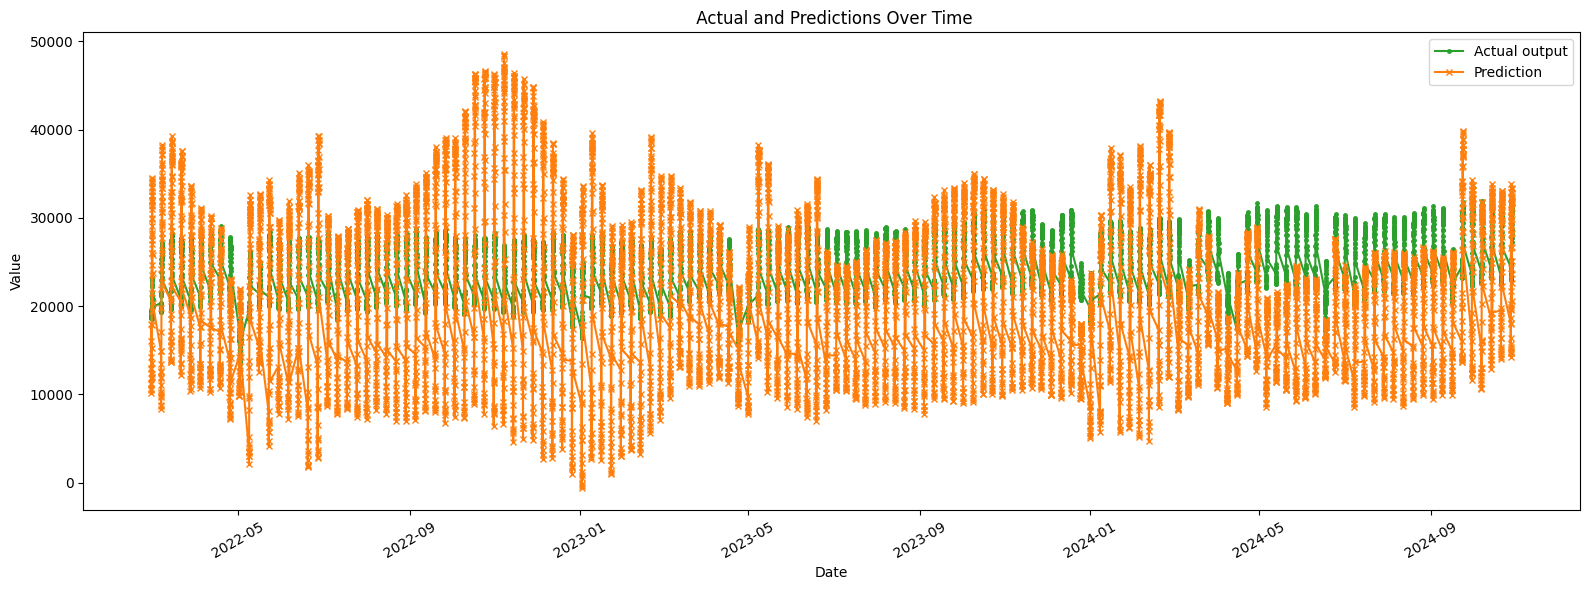

2/2 [==============================] - 0s 5ms/step
before dropna
                         Prediksi        Aktual
Date                                           
2024-12-30 00:00:00  13984.352539  21937.349609
2024-12-30 00:30:00  12422.455078  22341.019531
2024-12-30 01:00:00  12315.059570  22022.419922
2024-12-30 01:30:00  11159.258789  21774.810547
2024-12-30 02:00:00  10352.323242  21596.550781
...                           ...           ...
2025-10-27 21:30:00  24441.064453  29025.169922
2025-10-27 22:00:00  23364.011719  28335.880859
2025-10-27 22:30:00  23099.101562  27807.810547
2025-10-27 23:00:00  22256.236328  27508.160156
2025-10-27 23:30:00  20775.843750  26690.779297

[2112 rows x 2 columns]
after dropna
                         Prediksi        Aktual
Date                                           
2024-12-30 00:00:00  13984.352539  21937.349609
2024-12-30 00:30:00  12422.455078  22341.019531
2024-12-30 01:00:00  12315.059570  22022.419922
2024-12-30 01:30:00  11159.258789

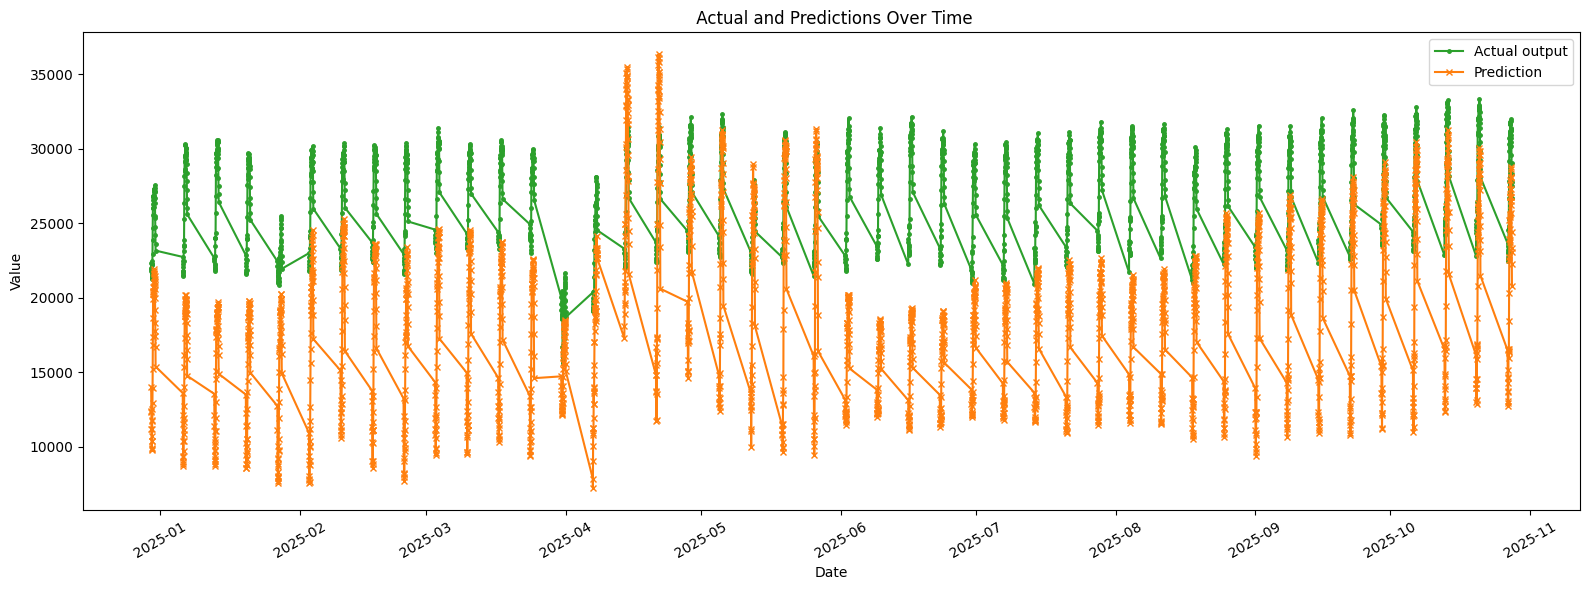

In [17]:

seed_vektor= [20]
for seed_value in seed_vektor:
    print(f"Running with seed: {seed_value}")
    tf.random.set_seed(seed_value)
    save_best_model_path = "CNN_monday8x_%s.h5"%seed_value
    model,     loss, MSE, MAE, MAPE, loss_history  = tensorflow_model(x_train, y_train, x_val, y_val, learning_rate=0.0001, target_MAE=0.001,  jumlah_epochs=100, jumlah_sampel_batch=1, 
                                                    jumlah_epoch_terbelakang=10,  save_best_model_path = save_best_model_path, 
                                                    validation_data=True, load_model=None, seed_value=seed_value)
    print(loss, MSE, MAE, MAPE)
    save_best_model_path
    model.load_weights(save_best_model_path)
    print("Loading best model from: ", save_best_model_path)
    print("model.evaluate(x_val, y_val): ", model.evaluate(x_val, y_val))
    predictions = model.predict(x_train[slice(None, None, label_width), :, :])
    predictions_reshaped = predictions.reshape(-1,)
    predictions_unscaled = inverse_scale_array(predictions_reshaped, orig_min=min_beban, orig_max=max_beban)
    df_pred_act = compute_error(x_train, data_training_awal['Beban'], ['Beban'], model, input_width,label_width, min_beban, max_beban)
    print(df_pred_act)
    df= df_pred_act.copy()
    plt.figure(figsize=(16, 6))

    # Plot the "Actual" as a green line with dot markers
    plt.plot(
        df.index, 
        df['Aktual'], 
        label='Actual output', 
        marker='.', 
        markersize=5, 
        color='#2ca02c', 
        zorder=-100
    )

    # Scatter plot for "Prediction" in orange X markers
    plt.plot(
        df.index, 
        df['Prediksi'], 
        marker='x', 
        markersize=5, 
        #edgecolors='k', 
        label='Prediction', 
        c='#ff7f0e', 
        #s=15
    )

    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=30)
    plt.title(' Actual and Predictions Over Time')
    plt.tight_layout()
    plt.show()







    df_pred_act = compute_error(x_val, data_validation_awal['Beban'], ['Beban'], model, input_width,label_width, min_beban, max_beban)
    print(df_pred_act)

    df= df_pred_act.copy()
    plt.figure(figsize=(16, 6))

    # Plot the "Actual" as a green line with dot markers
    plt.plot(
        df.index, 
        df['Aktual'], 
        label='Actual output', 
        marker='.', 
        markersize=5, 
        color='#2ca02c', 
        zorder=-100
    )

    # Scatter plot for "Prediction" in orange X markers
    plt.plot(
        df.index, 
        df['Prediksi'], 
        marker='x', 
        markersize=5, 
        #edgecolors='k', 
        label='Prediction', 
        c='#ff7f0e', 
        #s=15
    )

    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=30)
    plt.title(' Actual and Predictions Over Time')
    plt.tight_layout()
    plt.show()
